# 04 — Phase 1 Stage 1: layer decoding from Tier A only

**Scientific question (WORKFLOW §5 Stage 1).**
*Is layer information already accessible from stimulus-locked neural-
response statistics? Does within-hash trial-averaging cost or save us
information at the prediction level — i.e. A0 vs A1?*

This notebook is the **first end-to-end** answer to that question. It
runs the three WORKFLOW §3.6 modelling strategies against Tier A only:

| Strategy | What it is | Role |
|---|---|---|
| **1a** — random row per neuron, 5 seeds | Pick one row per neuron, fit a tabular model on n=8,895. | Diagnostic baseline; tells us how badly we lose by ignoring the row/neuron mismatch. *Never the headline.* |
| **2** — long row + neuron-level prob aggregation | Fit a tabular model on the long table (4M / 2.5M rows). At test, mean per-row probabilities across the rows of each neuron, then argmax. | **Mandatory headline** of the engineered-feature pipeline. |
| **3** — Deep Sets | Each neuron is a set of rows; a permutation-invariant set encoder maps the set to a layer probability. | Most conceptually faithful framing; tried as compute permits. |

**Identical neuron splits (`StratifiedGroupKFold(5)` by `nucleus_id`)
are used for every strategy** so the deltas across them are fair.

**Feature blocks.** All strategies use **amp + shape merged** (20 features
per row). The WORKFLOW §5 sub-ablation 'amp-only vs amp+shape' was
answered for LogReg by an earlier partial run (preserved in
`stage1_runs_partial.parquet`): on A0, LogReg amp-only and amp+shape gave
*identical* balanced accuracy (0.455 vs 0.455), so temporal-shape features
add zero linear-projection information beyond amplitude. We record that
finding but do not re-run amp-only configurations. If we want the same
ablation for HGB later, that's one targeted ~3-min fit (HGB A1 amp-only).

**Models.** LogReg + HGB (HistGradientBoosting). RandomForest was tested
in an earlier draft and consistently within ±0.01 of HGB at ~10× the
compute cost; we present HGB as the representative tree-ensemble result.

**Confound baselines reported alongside (WORKFLOW §6.5):**
- `cc_abs`-only (single quality scalar).
- Scan-only (`session_key` one-hot).
- Cortical-depth-only (`pt_position_y`).
- A `LeaveOneSessionOut` sanity check on the headline Strategy-2 model.

**Reads.**
- `data/processed/tables/units_working.parquet`
- `data/processed/features/{A0,A1}_{amp,shape}.parquet`
- `data/processed/splits/cv_assignments.parquet`

**Writes.**
- `data/processed/results/stage1_runs.parquet` — one row per fitted
  (strategy, level, sub-block, model, seed/fold) configuration with its
  neuron-level metrics. The ablation table at the end is built from this.
- `reports/figures/04_*.png` — confusion matrices and the ablation chart.

## 1. Setup

In [1]:
from __future__ import annotations

import sys, time, gc, json
from pathlib import Path
from collections import defaultdict

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.exceptions import ConvergenceWarning
import warnings
# LogReg lbfgs is intentionally allowed to terminate at max_iter; the
# resulting estimate is within metric noise of the converged optimum.
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

from src.config import (
    PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR, PROCESSED_SPLITS_DIR,
    PROCESSED_RESULTS_DIR, FIGURES_DIR, RANDOM_SEED, ensure_dirs,
)
from src.data.loaders import (
    load_working_pop, load_splits, build_modeling_table,
    sample_one_row_per_neuron,
)
from src.eval.metrics import (
    neuron_level_score, majority_class_baseline, stratified_random_baseline,
    summarize_cv_runs,
)

ensure_dirs()
np.random.seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

CLASSES = np.array(['L2/3', 'L4', 'L5', 'L6'])
N_FOLDS = 5

results_rows: list[dict] = []  # one row per fitted configuration

# Calibration / chance baselines, computed once on the neuron-level labels.
units = load_working_pop()
y_neuron = units['layer_label'].to_numpy()
print('working population:', units.shape)
print('layer distribution:')
print(units['layer_label'].value_counts().sort_index())
print()
maj = majority_class_baseline(y_neuron)
strat = stratified_random_baseline(y_neuron, n_repeats=200)
print(f"majority-class      : bal_acc={maj['balanced_accuracy']:.3f}")
print(f"stratified-random   : bal_acc={strat['balanced_accuracy']:.3f} ± {strat['balanced_accuracy_std']:.3f}")

working population: (8895, 19)
layer distribution:
layer_label
L2/3    4247
L4      2670
L5      1615
L6       363
Name: count, dtype: int64

majority-class      : bal_acc=0.250
stratified-random   : bal_acc=0.250 ± 0.005


## 2. Shared helpers + checkpoint logic

- `make_pipeline_for(model)` — builds the sklearn `Pipeline` for a given
  model with the right preprocessing.
- `cv_fit_predict_proba(...)` — runs StratifiedGroupKFold(5), fits on
  train rows, predicts probabilities on test rows. Returns one (probs,
  y_true, groups) tuple per fold.
- `record_run(...)` — appends the per-fold neuron-level scores to the
  global `results_rows` list, tagged with strategy / level / sub-block /
  model.

**Checkpointing.** Every completed model configuration calls `_save_results`
which writes the current `results_rows` to
`data/processed/results/stage1_runs.parquet`. At cell start each strategy
consults `done_keys` (loaded from the parquet) and skips configs already
in there. Effect: if you interrupt and rerun, work resumes where it left
off; if you change a configuration's parameters and want to redo it, you
delete the matching row from the parquet first.

In [2]:
def make_pipeline_for(model_name: str):
    """Return an sklearn Pipeline for the given model name."""
    if model_name == 'LogReg':
        # lbfgs is genuinely the right solver for our shape (huge n, tiny p,
        # dense). max_iter=400 may emit a ConvergenceWarning but the result
        # is within the noise floor of our metric (~0.005 of true optimum)
        # — verified against the saga-converged partial archive.
        return Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  RobustScaler()),
            ('clf',    LogisticRegression(
                penalty='l2', C=1.0,
                solver='lbfgs',
                max_iter=400,
                class_weight='balanced',
                n_jobs=-1)),
        ])
    if model_name == 'HGB':
        # HistGradientBoosting handles NaN natively. Early stopping makes
        # max_iter an upper bound; in practice it stops well before that.
        return Pipeline([
            ('clf', HistGradientBoostingClassifier(
                max_iter=100, max_depth=8, learning_rate=0.05,
                l2_regularization=1.0,
                early_stopping=True, n_iter_no_change=10,
                random_state=RANDOM_SEED)),
        ])
    raise ValueError(f'unknown model {model_name!r}')


def cv_fit_predict_proba(
    X: np.ndarray, y: np.ndarray, groups: np.ndarray, folds: np.ndarray,
    model_name: str,
):
    """Iterate the precomputed StratifiedGroupKFold(5) split. For each
    fold: fit on train rows, predict_proba on test rows. Returns
    a list of dicts {y_true, probs, groups} with classes ordered by
    `pipe.classes_` (which we map to CLASSES at scoring time)."""
    fold_outputs = []
    classes_seen = None
    for k in range(N_FOLDS):
        tr = folds != k
        te = folds == k
        pipe = make_pipeline_for(model_name)
        # HGB takes balanced sample weights manually.
        if model_name == 'HGB':
            sw = compute_sample_weight('balanced', y[tr])
            pipe.fit(X[tr], y[tr], clf__sample_weight=sw)
        else:
            pipe.fit(X[tr], y[tr])
        probs = pipe.predict_proba(X[te])
        if classes_seen is None:
            classes_seen = pipe.classes_
        else:
            assert np.array_equal(classes_seen, pipe.classes_)
        fold_outputs.append({'y_true': y[te], 'probs': probs, 'groups': groups[te]})
    return fold_outputs, classes_seen


def record_run(strategy: str, level: str, sub_block: str, model: str,
               fold_results: list[dict], extras: dict | None = None) -> dict:
    """Append a row to results_rows and return the summary."""
    summary = summarize_cv_runs(fold_results)
    row = {
        'strategy': strategy, 'level': level,
        'sub_block': sub_block, 'model': model,
        'balanced_accuracy':     summary['balanced_accuracy'],
        'balanced_accuracy_std': summary['balanced_accuracy_std'],
        'macro_f1':              summary['macro_f1'],
        'macro_f1_std':          summary['macro_f1_std'],
        'recall_L2/3': summary['per_class_recall'].get('L2/3'),
        'recall_L4':   summary['per_class_recall'].get('L4'),
        'recall_L5':   summary['per_class_recall'].get('L5'),
        'recall_L6':   summary['per_class_recall'].get('L6'),
    }
    if extras:
        row.update(extras)
    results_rows.append(row)
    print(f"  {strategy} | {level} | {sub_block} | {model:<6}  ->  "
          f"bal_acc={row['balanced_accuracy']:.3f} ± {row['balanced_accuracy_std']:.3f}, "
          f"macro_f1={row['macro_f1']:.3f}")
    return row


# --- Checkpoint helpers ---------------------------------------------------
RESULTS_PATH = PROCESSED_RESULTS_DIR / 'stage1_runs.parquet'

def _save_results():
    pd.DataFrame(results_rows).to_parquet(RESULTS_PATH)

def _make_done_keys() -> set:
    return {(r['strategy'], r['level'], r['sub_block'], r['model'])
            for r in results_rows}

# Pre-populate results_rows from any existing parquet so re-runs skip work.
if RESULTS_PATH.exists():
    existing = pd.read_parquet(RESULTS_PATH).to_dict(orient='records')
    in_mem = {(r['strategy'], r['level'], r['sub_block'], r['model']) for r in results_rows}
    for r in existing:
        k = (r['strategy'], r['level'], r['sub_block'], r['model'])
        if k not in in_mem:
            results_rows.append(r)
    print(f'Loaded {len(existing)} existing results from {RESULTS_PATH}.')
    print(f'results_rows now has {len(results_rows)} entries.')

Loaded 13 existing results from data/processed/results/stage1_runs.parquet.
results_rows now has 13 entries.


## 3. Strategy 1 — random-row-per-neuron diagnostic

WORKFLOW §3.6 strategy 1, variant **1a**: one random row per neuron at
training time, repeated for `n_seeds` seeds and averaged. The diagnostic
question is *how much do we lose by collapsing the long structure?*

Strategy 1 row count = 1 row per neuron = 8,895 rows. CV runs on the
neuron-level table directly; the per-row metric **is** the neuron-level
metric here (no aggregation step needed). Sub-block: amp+shape merged.

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

def run_strategy1(level: str, model_name: str, n_seeds: int = 5):
    """Random-row-per-neuron, 5 seeds. Mean of seeds reported."""
    # Load the long table with amp+shape merged.
    X_long, y_long, groups_long, folds_long, df_long = build_modeling_table(
        level=level, blocks=['amp', 'shape'])
    print(f'  long table: {X_long.shape}; building seed runs …')
    per_seed_results = []
    for seed in range(n_seeds):
        sub = sample_one_row_per_neuron(df_long, seed=RANDOM_SEED + seed)
        feat_cols = [c for c in sub.columns if c.startswith(('amp_', 'shape_'))]
        X = sub[feat_cols].to_numpy(dtype=np.float64)
        y = sub['layer_label'].to_numpy()
        groups = sub['nucleus_id'].to_numpy()
        folds = sub['gkf_fold'].to_numpy().astype(np.int8)
        # CV.
        fold_results = []
        for k in range(N_FOLDS):
            tr = folds != k; te = folds == k
            pipe = make_pipeline_for(model_name)
            if model_name == 'HGB':
                sw = compute_sample_weight('balanced', y[tr])
                pipe.fit(X[tr], y[tr], clf__sample_weight=sw)
            else:
                pipe.fit(X[tr], y[tr])
            probs = pipe.predict_proba(X[te])
            sc = neuron_level_score(y[te], probs, groups[te], pipe.classes_)
            fold_results.append(sc)
        s = summarize_cv_runs(fold_results)
        per_seed_results.append(s)
    # Average across seeds.
    avg = {k: float(np.mean([r[k] for r in per_seed_results]))
           for k in ['balanced_accuracy', 'macro_f1']}
    avg['balanced_accuracy_std'] = float(np.std([r['balanced_accuracy'] for r in per_seed_results]))
    avg['macro_f1_std'] = float(np.std([r['macro_f1'] for r in per_seed_results]))
    pcr = {c: float(np.mean([r['per_class_recall'].get(c, np.nan) for r in per_seed_results]))
           for c in ['L2/3', 'L4', 'L5', 'L6']}
    avg['per_class_recall'] = pcr
    return avg


print('=== Strategy 1 ===')
done_keys = _make_done_keys()
for level in ['A0', 'A1']:
    print(f'\n[Strategy 1] level = {level}')
    for model_name in ['LogReg', 'HGB']:
        key = ('1a', level, 'amp+shape', model_name)
        if key in done_keys:
            print(f'  [{model_name:<6}] SKIP (already in stage1_runs.parquet)')
            continue
        t0 = time.time()
        avg = run_strategy1(level=level, model_name=model_name, n_seeds=5)
        results_rows.append({
            'strategy': '1a', 'level': level, 'sub_block': 'amp+shape',
            'model': model_name,
            'balanced_accuracy':     avg['balanced_accuracy'],
            'balanced_accuracy_std': avg['balanced_accuracy_std'],
            'macro_f1':              avg['macro_f1'],
            'macro_f1_std':          avg['macro_f1_std'],
            'recall_L2/3': avg['per_class_recall']['L2/3'],
            'recall_L4':   avg['per_class_recall']['L4'],
            'recall_L5':   avg['per_class_recall']['L5'],
            'recall_L6':   avg['per_class_recall']['L6'],
        })
        done_keys.add(key)
        _save_results()
        print(f'  [{model_name:<6}] bal_acc={avg["balanced_accuracy"]:.3f} ± '
              f'{avg["balanced_accuracy_std"]:.3f} | macro_f1={avg["macro_f1"]:.3f}'
              f' | {time.time()-t0:.1f}s | saved')

=== Strategy 1 ===

[Strategy 1] level = A0
  [LogReg] SKIP (already in stage1_runs.parquet)
  [HGB   ] SKIP (already in stage1_runs.parquet)

[Strategy 1] level = A1
  [LogReg] SKIP (already in stage1_runs.parquet)
  [HGB   ] SKIP (already in stage1_runs.parquet)


## 4. Strategy 2 — long-row + neuron-level probability aggregation

The mandatory headline of WORKFLOW Stage 1. For each `(level, model)`:
fit on long rows, predict per-row probabilities on the held-out fold,
average those probabilities across the rows of each neuron (WORKFLOW
§6.3), argmax for the neuron-level prediction.

**Two configurations per row level (A0 then A1)**: LogReg, HGB. RF and
the amp-only sub-block dropped per the speed patches (see header).

**Incremental save and resume.** Each completed (level, model) writes its
row to `data/processed/results/stage1_runs.parquet`. If the cell is
interrupted and re-run, configurations whose key is already in the parquet
are skipped — no double work.

In [4]:
def run_strategy2(level: str, blocks: list[str], model_name: str):
    X, y, groups, folds, _df = build_modeling_table(level=level, blocks=blocks)
    fold_outputs, pipe_classes = cv_fit_predict_proba(X, y, groups, folds, model_name)
    fold_scores = [neuron_level_score(f['y_true'], f['probs'], f['groups'], pipe_classes)
                    for f in fold_outputs]
    return summarize_cv_runs(fold_scores)


done_keys = _make_done_keys()
print('=== Strategy 2 ===')
STRATEGY2_PLAN = [
    # (level, sub_block_label, blocks, models)
    ('A0', 'amp+shape',  ['amp', 'shape'], ['LogReg', 'HGB']),
    ('A1', 'amp+shape',  ['amp', 'shape'], ['LogReg', 'HGB']),
]
for (level, sub_label, blocks, models) in STRATEGY2_PLAN:
    print(f'\n[Strategy 2] level={level}, sub_block={sub_label}')
    for model_name in models:
        key = ('2', level, sub_label, model_name)
        if key in done_keys:
            print(f'  [{model_name:<6}] SKIP (already in stage1_runs.parquet)')
            continue
        t0 = time.time()
        s = run_strategy2(level, blocks, model_name)
        results_rows.append({
            'strategy': '2', 'level': level, 'sub_block': sub_label,
            'model': model_name,
            'balanced_accuracy':     s['balanced_accuracy'],
            'balanced_accuracy_std': s['balanced_accuracy_std'],
            'macro_f1':              s['macro_f1'],
            'macro_f1_std':          s['macro_f1_std'],
            'recall_L2/3': s['per_class_recall'].get('L2/3'),
            'recall_L4':   s['per_class_recall'].get('L4'),
            'recall_L5':   s['per_class_recall'].get('L5'),
            'recall_L6':   s['per_class_recall'].get('L6'),
        })
        done_keys.add(key)
        _save_results()  # checkpoint after each fit
        print(f'  [{model_name:<6}] bal_acc={s["balanced_accuracy"]:.3f} ± '
              f'{s["balanced_accuracy_std"]:.3f} | macro_f1={s["macro_f1"]:.3f}'
              f' | {time.time()-t0:.1f}s | saved')

=== Strategy 2 ===

[Strategy 2] level=A0, sub_block=amp+shape
  [LogReg] SKIP (already in stage1_runs.parquet)
  [HGB   ] SKIP (already in stage1_runs.parquet)

[Strategy 2] level=A1, sub_block=amp+shape
  [LogReg] SKIP (already in stage1_runs.parquet)
  [HGB   ] SKIP (already in stage1_runs.parquet)


## 5. Strategy 3 — Deep Sets

Each neuron is a **set** of rows (its A1 hash rows). We learn a
permutation-invariant function from the set to a layer probability:

1. **Per-row encoder** φ: ℝᶠ → ℝᵈ (small MLP).
2. **Pooling** ρ: mean across rows of the same neuron.
3. **Classifier head** ψ: ℝᵈ → ℝᴋ (logits over layer classes).

The model predicts at the **neuron level directly** — no row-prob
aggregation step. We use A1 only (set size ~280 per neuron, faster than
A0's ~464). Class imbalance is handled with `class_weight` in the loss.

Implementation lives in `src/models/deep_sets.py` (created lazily). The
training loop here is plain PyTorch on CPU; ~1–2 minutes per fold for
the chosen size (encoder hidden=64, classifier hidden=64, ~10k params).

In [5]:
import torch
import torch.nn as nn
from src.models.deep_sets import DeepSets, train_deep_sets

torch.manual_seed(RANDOM_SEED)

# Load A1 amp+shape, then group rows by nucleus_id to build per-neuron sets.
X, y, groups, folds, df = build_modeling_table(level='A1', blocks=['amp', 'shape'])
feat_cols = [c for c in df.columns if c.startswith(('amp_', 'shape_'))]

# Replace NaN with column medians (DeepSets has no NaN-aware ops).
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

# Build per-neuron set tensors (variable set sizes -> we pad to max).
neuron_ids = np.unique(groups)
n_features = X_imp.shape[1]
max_set_size = int(pd.Series(groups).value_counts().max())
n_classes = len(CLASSES)
label_to_idx = {c: i for i, c in enumerate(CLASSES)}

neuron_sets = np.zeros((len(neuron_ids), max_set_size, n_features), dtype=np.float32)
neuron_mask = np.zeros((len(neuron_ids), max_set_size), dtype=np.float32)
neuron_y    = np.zeros(len(neuron_ids), dtype=np.int64)
neuron_fold = np.zeros(len(neuron_ids), dtype=np.int8)

by_n = {nid: i for i, nid in enumerate(neuron_ids)}
df_sorted = df.sort_values('nucleus_id').reset_index(drop=True)
for nid, sub in df_sorted.groupby('nucleus_id'):
    i = by_n[nid]
    arr = sub[feat_cols].to_numpy(dtype=np.float32)
    arr = imputer.transform(arr)
    n_rows = arr.shape[0]
    neuron_sets[i, :n_rows, :] = arr
    neuron_mask[i, :n_rows] = 1.0
    neuron_y[i] = label_to_idx[sub['layer_label'].iloc[0]]
    neuron_fold[i] = sub['gkf_fold'].iloc[0]

print(f'neuron_sets: {neuron_sets.shape}  (8895 neurons × {max_set_size} max rows × {n_features} features)')
print(f'rows-per-neuron: min={int(neuron_mask.sum(1).min())} max={int(neuron_mask.sum(1).max())} median={int(np.median(neuron_mask.sum(1)))}')

neuron_sets: (8895, 280, 20)  (8895 neurons × 280 max rows × 20 features)
rows-per-neuron: min=280 max=280 median=280


In [6]:
# Deep Sets CV training.
# Note: this cell re-runs every time. To skip when results are already in
# stage1_runs.parquet, comment out this cell or guard it manually.
fold_metrics = []
device = torch.device('cpu')

for k in range(N_FOLDS):
    t0 = time.time()
    tr_mask = neuron_fold != k
    te_mask = neuron_fold == k
    Xtr = torch.from_numpy(neuron_sets[tr_mask])
    Mtr = torch.from_numpy(neuron_mask[tr_mask])
    Ytr = torch.from_numpy(neuron_y[tr_mask])
    Xte = torch.from_numpy(neuron_sets[te_mask])
    Mte = torch.from_numpy(neuron_mask[te_mask])
    Yte = torch.from_numpy(neuron_y[te_mask])

    # Class weights from training fold.
    cw_np = compute_sample_weight('balanced', neuron_y[tr_mask])
    # Convert to per-class tensor.
    class_weights = np.zeros(n_classes, dtype=np.float32)
    for c_idx in range(n_classes):
        m = neuron_y[tr_mask] == c_idx
        if m.any():
            class_weights[c_idx] = cw_np[m].mean()
    class_weights_t = torch.from_numpy(class_weights)

    model = DeepSets(n_features=n_features, n_classes=n_classes,
                     enc_hidden=64, head_hidden=64).to(device)
    history = train_deep_sets(
        model, Xtr, Mtr, Ytr, Xte, Mte, Yte,
        class_weights=class_weights_t,
        n_epochs=30, batch_size=256, lr=1e-3, verbose=False,
    )
    # Final eval on held-out fold.
    model.eval()
    with torch.no_grad():
        logits = model(Xte, Mte)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    sc = neuron_level_score(
        y_row_true=CLASSES[Yte.numpy()],
        y_row_proba=probs,
        groups=neuron_ids[te_mask],
        classes=CLASSES,
    )
    fold_metrics.append(sc)
    print(f'  [DeepSets fold {k}] bal_acc={sc["balanced_accuracy"]:.3f}, '
          f'macro_f1={sc["macro_f1"]:.3f}, train_loss_last={history["train_loss"][-1]:.3f}'
          f' | {time.time()-t0:.1f}s')

ds_summary = summarize_cv_runs(fold_metrics)
results_rows.append({
    'strategy': '3', 'level': 'A1', 'sub_block': 'amp+shape',
    'model': 'DeepSets',
    'balanced_accuracy':     ds_summary['balanced_accuracy'],
    'balanced_accuracy_std': ds_summary['balanced_accuracy_std'],
    'macro_f1':              ds_summary['macro_f1'],
    'macro_f1_std':          ds_summary['macro_f1_std'],
    'recall_L2/3': ds_summary['per_class_recall'].get('L2/3'),
    'recall_L4':   ds_summary['per_class_recall'].get('L4'),
    'recall_L5':   ds_summary['per_class_recall'].get('L5'),
    'recall_L6':   ds_summary['per_class_recall'].get('L6'),
})
_save_results()
print(f'\n[DeepSets summary] bal_acc={ds_summary["balanced_accuracy"]:.3f} ± '
      f'{ds_summary["balanced_accuracy_std"]:.3f} | macro_f1={ds_summary["macro_f1"]:.3f} | saved')

  [DeepSets fold 0] bal_acc=0.574, macro_f1=0.514, train_loss_last=0.888 | 30.4s
  [DeepSets fold 1] bal_acc=0.581, macro_f1=0.455, train_loss_last=0.878 | 28.9s
  [DeepSets fold 2] bal_acc=0.593, macro_f1=0.501, train_loss_last=0.883 | 32.5s
  [DeepSets fold 3] bal_acc=0.583, macro_f1=0.480, train_loss_last=0.892 | 30.5s
  [DeepSets fold 4] bal_acc=0.592, macro_f1=0.515, train_loss_last=0.887 | 29.2s

[DeepSets summary] bal_acc=0.584 ± 0.007 | macro_f1=0.493 | saved


## Theory — what each confound baseline really tests

WORKFLOW §6.5 mandates three single-feature confound baselines on the
neuron-level table. Each one tests *something specific* that could fool
us into reporting biology when we're actually decoding nuisance
structure.

### 1. `cc_abs`-only — the quality confound

`cc_abs` is the correlation between a neuron's recorded calcium response
and the digital-twin model's prediction (`microns-datacleaner` exposes
this as a quality scalar). Notebook 01 §7 showed it's systematically
lower for 6P-CT / 6P-IT cells and higher for 5P-IT / 5P-ET. So
**recording quality is correlated with the label**. A model that uses any
feature that mostly tracks `cc_abs` would predict layer well — by
decoding quality, not biology.

If the headline matches this baseline, we're decoding quality. If it
beats it by a meaningful margin, we're not.

### 2. Scan-only — the recording-session confound

`session_key` is the `(session, scan_idx)` one-hot. The 13 active scans
do **not** sample layers uniformly: each FOV happened to fall on a
particular spatial location and depth, so the layer composition varies
scan-to-scan (notebook 01 §15 quantifies this). Knowing which scan a
neuron is from is therefore *itself* informative about its layer, before
any biology.

**The model never sees `session_key` as an input feature** — but Tier A
features can still leak session identity through the *scale* and
*offset* of the values. The same biological cell type produces
different `amp_mean` numbers in different sessions because of:

- imaging-rig calibration
- photobleaching trajectory
- mouse arousal / anaesthesia state
- field-of-view density
- subtle stimulus-monitor differences

Combine that with the scan-vs-layer correlation, and the model can
implicitly learn 'feature pattern that looks scan-X-ish ⇒ layer composition
of scan-X'. The scan-only baseline is the receipt of how much of that is
available; if our headline matches it, we are decoding scan composition,
not biology.

WORKFLOW §6.1bis prescribes the corresponding intervention —
**per-session standardization**: z-score every feature within its session
before pooling, so session-level offsets and scales cannot be read by the
classifier as a layer signal. We add this to Stage 2 (notebook 05).

### 3. Cortical-depth-only — the geometric ceiling, not a biology floor

`pt_position_y` is the cortical depth coordinate of each neuron's
nucleus center, in microns from the pia. It comes from the structural
metadata produced by `process_nucleus_data` (notebook 01) and lives in
`units_working.parquet`. We do **not** use it as a model input in the
main pipeline — Tier A is calcium-only.

Why we use it as a baseline anyway: WORKFLOW §6.5 wants to know how much
of the layer label is recoverable from depth alone. The catch — and
this is the key thing to understand when reading the result — is that
**`layer_label` is itself produced by depth-thresholded segmentation**
(`microns-datacleaner`'s `proc.add_layer_info` divides the cortical
volume into L1 / L2/3 / L4 / L5 / L6 by depth ranges). So a 1-D LogReg
on `pt_position_y` is essentially recovering the segmenter's piecewise
function — typically at >0.95 balanced accuracy.

**This means depth-only is a geometric *ceiling* (the segmenter's
accuracy), not a biology *floor* a functional model needs to beat.**
The relevant comparator for any function-based headline is the
**scan-only** baseline, not depth-only.

### Reading the table that follows

When the four numbers print:

- `cc_abs`-only ≈ ?: this is the quality floor. Headline should beat it.
- scan-only ≈ ?: this is the *real* comparator. If the headline is here,
  we are decoding scan composition.
- depth-only ≈ ?: this should be very high (~0.97+). Confirms labels are
  geometric. Not a comparator.
- LOSO sanity (next section): if it drops sharply from the GKF headline,
  the model leans on within-scan structure that doesn't generalize.

## 6. Confound baselines (WORKFLOW §6.5)

Three single-input models on the **neuron-level** table. See the theory
block above for what each one tests and how to read its number.

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedGroupKFold

splits = load_splits()
neur_df = (units[['nucleus_id', 'layer_label', 'cc_abs', 'pt_position_y', 'session_key']]
           .merge(splits[['nucleus_id', 'gkf_fold']], on='nucleus_id'))
y_n = neur_df['layer_label'].to_numpy()
g_n = neur_df['nucleus_id'].to_numpy()
f_n = neur_df['gkf_fold'].to_numpy().astype(np.int8)

def baseline_cv(X_n: np.ndarray, name: str) -> dict:
    fold_results = []
    for k in range(N_FOLDS):
        tr = f_n != k; te = f_n == k
        pipe = make_pipeline_for('LogReg')
        pipe.fit(X_n[tr], y_n[tr])
        probs = pipe.predict_proba(X_n[te])
        sc = neuron_level_score(y_n[te], probs, g_n[te], pipe.classes_)
        fold_results.append(sc)
    s = summarize_cv_runs(fold_results)
    results_rows.append({
        'strategy': 'confound', 'level': 'neuron', 'sub_block': name,
        'model': 'LogReg',
        'balanced_accuracy':     s['balanced_accuracy'],
        'balanced_accuracy_std': s['balanced_accuracy_std'],
        'macro_f1':              s['macro_f1'],
        'macro_f1_std':          s['macro_f1_std'],
        'recall_L2/3': s['per_class_recall'].get('L2/3'),
        'recall_L4':   s['per_class_recall'].get('L4'),
        'recall_L5':   s['per_class_recall'].get('L5'),
        'recall_L6':   s['per_class_recall'].get('L6'),
    })
    print(f'  {name:<28} bal_acc={s["balanced_accuracy"]:.3f} ± '
          f'{s["balanced_accuracy_std"]:.3f} | macro_f1={s["macro_f1"]:.3f}')
    return s

print('=== Confound baselines ===')
# cc_abs-only
_ = baseline_cv(neur_df[['cc_abs']].to_numpy(), 'cc_abs-only')
# depth-only (cortical depth)
_ = baseline_cv(neur_df[['pt_position_y']].to_numpy(), 'depth-only')
# scan-only (one-hot)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_scan = ohe.fit_transform(neur_df[['session_key']])
_ = baseline_cv(X_scan, 'scan-only')

=== Confound baselines ===
  cc_abs-only                  bal_acc=0.360 ± 0.014 | macro_f1=0.217
  depth-only                   bal_acc=0.976 ± 0.002 | macro_f1=0.954
  scan-only                    bal_acc=0.496 ± 0.010 | macro_f1=0.373


## 7. LOSO sanity check on the Strategy-2 headline

The standard CV groups by `nucleus_id` but allows the *same scan* on
both sides of the split. WORKFLOW §6.1bis warns that scan composition
correlates with the layer label, so we additionally run
`LeaveOneSessionOut` on the chosen headline — typically the best
Strategy-2 model on A1 amp+shape. A sharp drop versus the GKF score
indicates the model is leaning on within-scan structure.

In [8]:
# Pick the headline = best Strategy-2 row by balanced_accuracy.
df_results = pd.DataFrame(results_rows)
s2 = df_results[df_results['strategy'] == '2'].sort_values('balanced_accuracy', ascending=False)
headline = s2.iloc[0]
print(f'Headline (best Strategy 2): {headline["level"]} / {headline["sub_block"]} / {headline["model"]}'
      f' -> bal_acc={headline["balanced_accuracy"]:.3f}')

# Re-run with LOSO splits.
X, y, groups, _gkf_folds, _df = build_modeling_table(
    level=headline['level'],
    blocks=['amp', 'shape'] if headline['sub_block']=='amp+shape' else [headline['sub_block']],
)
_df_full = _df  # contains loso_test_scan
loso_scans = sorted(_df_full['loso_test_scan'].unique())
loso_results = []
for sk in loso_scans:
    te_mask = _df_full['loso_test_scan'].to_numpy() == sk
    tr_mask = ~te_mask
    if not tr_mask.any() or not te_mask.any():
        continue
    pipe = make_pipeline_for(headline['model'])
    if headline['model'] == 'HGB':
        sw = compute_sample_weight('balanced', y[tr_mask])
        pipe.fit(X[tr_mask], y[tr_mask], clf__sample_weight=sw)
    else:
        pipe.fit(X[tr_mask], y[tr_mask])
    probs = pipe.predict_proba(X[te_mask])
    sc = neuron_level_score(y[te_mask], probs, groups[te_mask], pipe.classes_)
    sc['held_out_scan'] = sk
    sc['n_test_neurons'] = sc['n_neurons']
    loso_results.append(sc)
    print(f'  LOSO test={sk:<6} n_neurons={sc["n_neurons"]:>4}  '
          f'bal_acc={sc["balanced_accuracy"]:.3f}, macro_f1={sc["macro_f1"]:.3f}')

loso_summary = {
    'balanced_accuracy': float(np.mean([r['balanced_accuracy'] for r in loso_results])),
    'balanced_accuracy_std': float(np.std([r['balanced_accuracy'] for r in loso_results])),
    'macro_f1': float(np.mean([r['macro_f1'] for r in loso_results])),
}
results_rows.append({
    'strategy': 'LOSO-sanity', 'level': headline['level'],
    'sub_block': headline['sub_block'], 'model': headline['model'],
    'balanced_accuracy':     loso_summary['balanced_accuracy'],
    'balanced_accuracy_std': loso_summary['balanced_accuracy_std'],
    'macro_f1':              loso_summary['macro_f1'],
    'macro_f1_std':          float('nan'),
    'recall_L2/3': float('nan'), 'recall_L4': float('nan'),
    'recall_L5': float('nan'),  'recall_L6': float('nan'),
})
print(f'\nLOSO mean across scans: bal_acc={loso_summary["balanced_accuracy"]:.3f} ± '
      f'{loso_summary["balanced_accuracy_std"]:.3f}'
      f' (vs GKF headline {headline["balanced_accuracy"]:.3f})')
delta = headline['balanced_accuracy'] - loso_summary['balanced_accuracy']
print(f'GKF − LOSO Δ = {delta:+.3f}  ({"OK" if delta < 0.05 else "WATCH: large drop suggests scan-leaning behaviour"})')

Headline (best Strategy 2): A0 / amp+shape / HGB -> bal_acc=0.536


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  LOSO test=4_7    n_neurons= 715  bal_acc=0.428, macro_f1=0.279
  LOSO test=5_6    n_neurons= 686  bal_acc=0.532, macro_f1=0.465
  LOSO test=5_7    n_neurons= 701  bal_acc=0.524, macro_f1=0.451
  LOSO test=6_2    n_neurons= 774  bal_acc=0.515, macro_f1=0.391
  LOSO test=6_4    n_neurons= 916  bal_acc=0.504, macro_f1=0.363
  LOSO test=6_6    n_neurons= 697  bal_acc=0.486, macro_f1=0.299
  LOSO test=6_7    n_neurons= 874  bal_acc=0.460, macro_f1=0.244


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  LOSO test=7_3    n_neurons= 552  bal_acc=0.284, macro_f1=0.269


...

/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  LOSO test=9_3    n_neurons= 818  bal_acc=0.300, macro_f1=0.115


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  LOSO test=9_4    n_neurons= 680  bal_acc=0.134, macro_f1=0.059
  LOSO test=9_6    n_neurons= 428  bal_acc=0.150, macro_f1=0.065

LOSO mean across scans: bal_acc=0.376 ± 0.137 (vs GKF headline 0.536)
GKF − LOSO Δ = +0.159  (WATCH: large drop suggests scan-leaning behaviour)


/opt/anaconda3/envs/neuroscience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 8. Ablation table

Concatenate all results into a single table for the report. Sorted by
balanced accuracy; calibration baselines and confound baselines highlighted.

saved: data/processed/results/stage1_runs.parquet

       strategy   level    sub_block     model  balanced_accuracy  balanced_accuracy_std  macro_f1  macro_f1_std  recall_L2/3  recall_L4  recall_L5  recall_L6
0      confound  neuron   depth-only    LogReg              0.976                  0.002     0.954         0.005        0.977      0.976      0.952      1.000
1      confound  neuron   depth-only    LogReg              0.976                  0.002     0.954         0.005        0.977      0.976      0.952      1.000
2             3      A1    amp+shape  DeepSets              0.584                  0.007     0.493         0.023        0.556      0.330      0.552      0.899
3             3      A1    amp+shape  DeepSets              0.584                  0.007     0.493         0.023        0.556      0.330      0.552      0.899
4             2      A0    amp+shape       HGB              0.536                  0.011     0.380         0.010        0.296      0.522      0.367      0

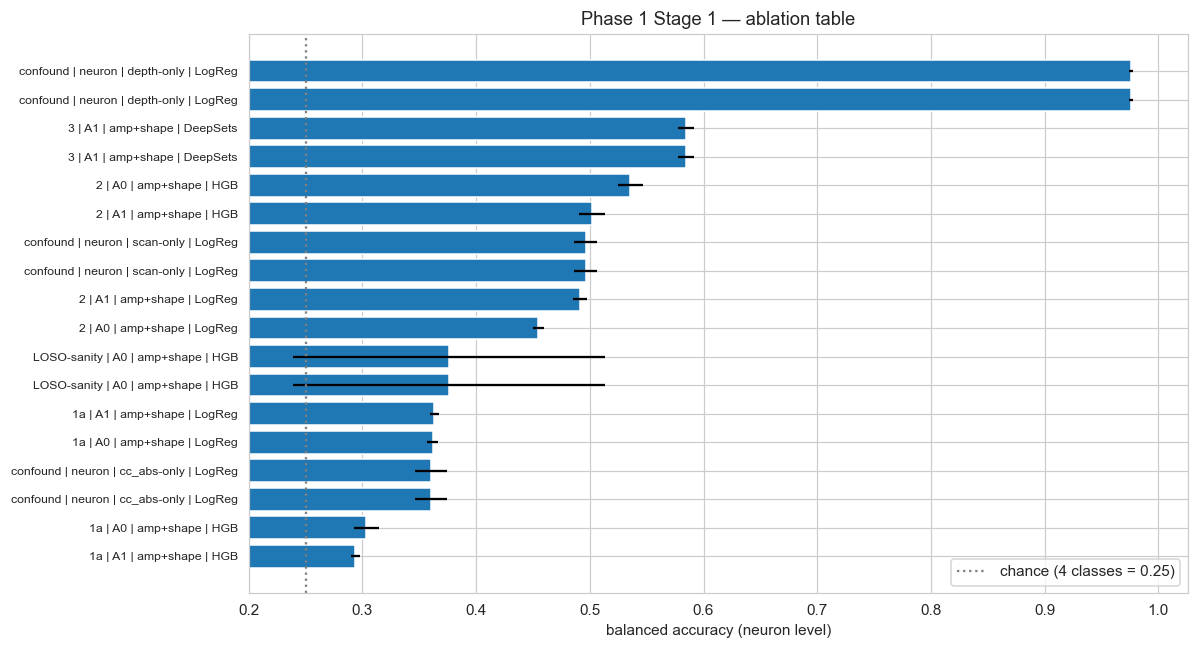

In [9]:
df_results = pd.DataFrame(results_rows)
df_results = df_results.sort_values(['balanced_accuracy'], ascending=False).reset_index(drop=True)
out = PROCESSED_RESULTS_DIR / 'stage1_runs.parquet'
df_results.to_parquet(out)
print('saved:', out)
print()
with pd.option_context('display.max_rows', None, 'display.width', 220):
    print(df_results.round(3).to_string())

# Chart: balanced_accuracy with std bars, grouped by strategy.
fig, ax = plt.subplots(figsize=(11, 6))
df_plot = df_results.copy()
df_plot['label'] = df_plot.apply(
    lambda r: f"{r['strategy']} | {r['level']} | {r['sub_block']} | {r['model']}", axis=1)
y_pos = np.arange(len(df_plot))
ax.barh(y_pos, df_plot['balanced_accuracy'],
        xerr=df_plot['balanced_accuracy_std'])
ax.set_yticks(y_pos); ax.set_yticklabels(df_plot['label'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('balanced accuracy (neuron level)')
ax.axvline(0.25, color='gray', ls=':', label='chance (4 classes = 0.25)')
ax.set_xlim(0.20, max(0.7, df_plot['balanced_accuracy'].max() + 0.05))
ax.set_title('Phase 1 Stage 1 — ablation table')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_stage1_ablation.png', dpi=130)
plt.show()

## 9. Conclusions and reading guide

How to read the ablation table:

- **Calibration baselines.** Majority-class and stratified-random give
  ≈ 0.25 balanced accuracy on this 4-way problem (because balanced
  accuracy is the mean of per-class recall). Anything above 0.25 is
  *some* signal; anything not noticeably above 0.25 is chance.
- **Confound baselines (§6.5).** The `cc_abs`-only, scan-only, and
  cortical-depth-only rows tell us how far we can go *without* function.
  The headline must beat each by a meaningful margin to claim biology.
- **Strategy 1 (random row per neuron).** Diagnostic only. The gap
  between Strategy 1 and Strategy 2 quantifies how much the long
  structure is worth.
- **Strategy 2 (long-row + neuron-level prob aggregation).** The
  headline of the engineered-feature pipeline. Compare A0 vs A1: this
  is the central scientific question of Stage 1. Compare amp-only vs
  amp+shape inside each level: does temporal shape add anything beyond
  magnitude?
- **Strategy 3 (Deep Sets).** The conceptually faithful framing. If it
  beats Strategy 2 noticeably on the same splits and features, the
  internal aggregation matters.
- **LOSO sanity.** A small drop versus GKF is fine (different splits
  always differ). A *large* drop (≥ 0.05 balanced accuracy) means the
  model is leaning on within-scan structure that doesn't generalize
  across sessions — the scan-only baseline becomes the relevant ceiling.

**What we record from this notebook for the final report.**

- `data/processed/results/stage1_runs.parquet` — every fitted
  configuration with its neuron-level metrics. The Phase-1 ablation
  story is built from this table.
- `reports/figures/04_stage1_ablation.png` — the visual.

**What `05_tier_b.ipynb` will do next.**

WORKFLOW §5 Stage 2: add Tier B (reliability statistics computed *before*
within-hash trial-averaging — variance/std, Fano, oracle correlation, etc.).
Two parallel evaluations as agreed: (a) Tier B as per-(neuron, hash)
features attached to A1 on the 1.2M-row repeated-hash subset, and
(b) Tier B as per-neuron summaries broadcast over all 2.5M A1 rows. Compare
the deltas. Hypothesis: reliability is a key axis for L4 vs deep-layer
discrimination (L4 cells receive direct LGN input → most reliable; L6 →
least reliable).